In [1]:
# this notebook is to use the [median DC sample] and find read noise.
#Modify the path to a directory on your machine
import os
os.environ["CRDS_PATH"] = "/home/hailin/Documents/CRDS"
os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"

# Packages that allow us to get information about objects:
import asdf
import copy
import shutil

# Numpy library:
import numpy as np

# For downloading data
import requests

# Astropy tools:
from astropy.io import fits
from astropy.utils.data import download_file
from astropy.visualization import ImageNormalize, ManualInterval, LogStretch

import matplotlib.pyplot as plt
import matplotlib as mpl

# Plotting tools:
from pipeline1_plotting_tools import download_files, plot_jump, plot_jumps, plot_ramp, plot_ramps, show_image, side_by_side

# Use this version for non-interactive plots (easier scrolling of the notebook)
%matplotlib inline

# Use this version (outside of Jupyter Lab) if you want interactive plots
#%matplotlib notebook

# List of possible data quality flags
from jwst.datamodels import dqflags

# The entire calwebb_detector1 pipeline
from jwst.pipeline import calwebb_detector1

# Individual steps that make up calwebb_detector1
from jwst.dq_init import DQInitStep
from jwst.saturation import SaturationStep
from jwst.superbias import SuperBiasStep
from jwst.ipc import IPCStep                                                                                    
from jwst.refpix import RefPixStep                                                                
from jwst.linearity import LinearityStep
from jwst.persistence import PersistenceStep
from jwst.dark_current import DarkCurrentStep
from jwst.jump import JumpStep
from jwst.ramp_fitting import RampFitStep
from jwst import datamodels

import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.special import gamma
from scipy.optimize import curve_fit, minimize

import jwst
print(jwst.__version__)

1.15.1


In [2]:
input_file_category = '3000s_exposure'
input_file_base = 'jw01121152001_02102_00002_nrs2'
jump_file = '../data/JWST/' + input_file_category + '/' + input_file_base + '/' + input_file_base + '_jumpstep.fits'
jump = datamodels.open(jump_file)

n_group = jump.data.shape[1]

photo_start = 0
photo_end   = n_group - 1
# bin 的范围
dn_min = -200
dn_max = 400
# Create a 4-dimensional map of ANY flags
dq_map_2d = np.sum(jump.groupdq[0, :, :, :] > 0, axis=0)
# Determine how many pixels are not GOOD
dq_map_indexes = np.where(dq_map_2d > 0)
bad_pix = np.sum(dq_map_2d > 0)
total_pix = 2048 * 2048
pre_mask = jump.data[0,photo_end,:,:] - jump.data[0,photo_start,:,:]

# dev：外加一个delta mask，相当于手搓版的jump mask
delta_thr = 100
jump_data = jump.data[0]
delta = (jump_data - np.roll(jump_data, 1, axis=0))[1:,:,:]
delta_map_2d = np.sum(np.abs(delta[:,:,:]) > delta_thr, axis=0)
delta_map_indexes = np.where(delta_map_2d > 0)


# 这次我们直接从超亮pixel的分布入手，mask掉超亮pixel周围的pixel
# 并且这次设计两套bad mask。越亮的区域需要的secondary越大。
mask = np.zeros_like(pre_mask, dtype=bool)
mosaic_size = 16
mosaic_half = int(mosaic_size / 2)
N_mosaic = int(2048 / mosaic_size)
edge_width = int(32/mosaic_size)

mask_thr_1 = 200
secondary_size_1 = 4
mask_thr_2 = 180
secondary_size_2 = 1
bad_mosaic_count = np.zeros((N_mosaic, N_mosaic))

# 现在可以直接从dq_map_indexes出发，对其进行pixel内的计数
bad_pix_map = (dq_map_2d > 0)
# 热力图，但是不带已经flagged的
for y in range(N_mosaic):  # jwst 指标先y后x
    for x in range(N_mosaic):
        bad_mosaic_count[y,x] = np.sum(bad_pix_map[y*mosaic_size:(y+1)*mosaic_size, x*mosaic_size:(x+1)*mosaic_size])
# 把马赛克化的mask汇总于此：
bad_mosaic_1  = (bad_mosaic_count>mask_thr_1)
bad_mosaic_2  = (bad_mosaic_count>mask_thr_2)
edge_mosaic = np.zeros((N_mosaic, N_mosaic), dtype=bool)
edge_mosaic[0:edge_width,:] = True
edge_mosaic[-edge_width:,:] = True
edge_mosaic[:,0:edge_width] = True
edge_mosaic[:,-edge_width:] = True
cols_mosaic = np.zeros((N_mosaic, N_mosaic), dtype=bool)
cols_mosaic[:,-14:-12] = True
cols_mosaic[:,28:30] = True
cols_mosaic[:,-4:-2] = True
secondary_mosaic_1 = np.zeros((N_mosaic, N_mosaic), dtype=bool) #coule be the most important
secondary_mosaic_2 = np.zeros((N_mosaic, N_mosaic), dtype=bool)
for y in range(N_mosaic):  # jwst 指标先y后x
    for x in range(N_mosaic):
        if  bad_mosaic_1[y,x] :
            y_min = np.max([y-secondary_size_1,0])
            x_min = np.max([x-secondary_size_1,0])
            y_max = np.min([y+secondary_size_1,N_mosaic-1])
            x_max = np.min([x+secondary_size_1,N_mosaic-1])
            secondary_mosaic_1[y_min:y_max+1,x_min:x_max+1] = True
        if  bad_mosaic_2[y,x] :
            y_min = np.max([y-secondary_size_2,0])
            x_min = np.max([x-secondary_size_2,0])
            y_max = np.min([y+secondary_size_2,N_mosaic-1])
            x_max = np.min([x+secondary_size_2,N_mosaic-1])
            secondary_mosaic_2[y_min:y_max+1,x_min:x_max+1] = True

mask_mosaic = bad_mosaic_1  + secondary_mosaic_1 + bad_mosaic_2  + secondary_mosaic_2 + edge_mosaic # + cols_mosaic
for y in range(N_mosaic):  # jwst 指标先y后x
    for x in range(N_mosaic):
        if  mask_mosaic[y,x]:
            mask[y*mosaic_size:(y+1)*mosaic_size, x*mosaic_size:(x+1)*mosaic_size] = True

# 最后再加上brightness_mask排除剩余的过亮点以及周围
brightness_mask = np.zeros_like(pre_mask, dtype=bool)
brightness_thr  = 150
brightness_size = 2
for y in range(2048):
    for x in range(2048):
        if  np.abs(pre_mask[y,x]) > brightness_thr: # not mask[y,x] and not dq_map_2d[y,x]
            y_min = np.max([y-brightness_size,0])
            x_min = np.max([x-brightness_size,0])
            y_max = np.min([y+brightness_size,2048-1])
            x_max = np.min([x+brightness_size,2048-1])
            brightness_mask[y_min:y_max+1,x_min:x_max+1] = True

mask = brightness_mask  + mask

# 现在mask和原bad pixel mask合并
masked_indexes = np.where(mask)

raw_photo_3 = pre_mask
raw_photo_3[dq_map_indexes] = np.nan
raw_photo_3[masked_indexes] = np.nan
raw_photo_flatten_3 = raw_photo_3.flatten()
nan_mask_3 = np.isnan(raw_photo_flatten_3)
photo_masked = raw_photo_flatten_3[~nan_mask_3]

In [20]:
# 需要五五分组平均吗？
c_regroup    = True
regroup_size = 35
if c_regroup:
    if n_group % regroup_size != 0:
        raise ValueError("第 2 维度的长度必须能被组大小整除")
    n_regroup = int(n_group / regroup_size)
    photo_regrouped = np.zeros((n_regroup, 2048, 2048))
    for i in range(n_regroup):
        photo_regrouped[i] = np.average(jump.data[0, i*regroup_size:(i+1)*regroup_size,:,:], axis = 0)
    photo = photo_regrouped
else:
    photo = jump.data[0]

delta = (photo - np.roll(photo, 1, axis=0))[1:,:,:]
delta_masked = np.zeros((photo.shape[0]-1, photo_masked.shape[0]))
for i in range(photo.shape[0]-1):
    delta_temp = delta[i]
    delta_temp[dq_map_indexes] = np.nan
    delta_temp[masked_indexes] = np.nan
    delta_temp_flatten = delta_temp.flatten()
    temp_mask = np.isnan(delta_temp_flatten)
    delta_masked[i] = delta_temp_flatten[~temp_mask]

In [21]:
def gaussian(x, amp, mean, stddev):
    return amp * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2))

In [22]:
dn_range = range(dn_min, dn_max)
initial_guess = [photo_masked.shape[0], 0, 13]
amp_grp = np.zeros(photo.shape[0]-1)
mean_grp = np.zeros(photo.shape[0]-1)
stddev_grp = np.zeros(photo.shape[0]-1)
for i in range(photo.shape[0]-1):
    rn_counts, rn_bin_edges = np.histogram(delta_masked[i], bins=range(dn_min, dn_max+1))
    params, covariance = curve_fit(gaussian, dn_range, rn_counts, p0=initial_guess)
    amp_fit, mean_fit, stddev_fit = params
    amp_grp[i] = amp_fit
    mean_grp[i] = mean_fit
    stddev_grp[i] = stddev_fit

In [23]:
mean_fit

2.2325008723124253

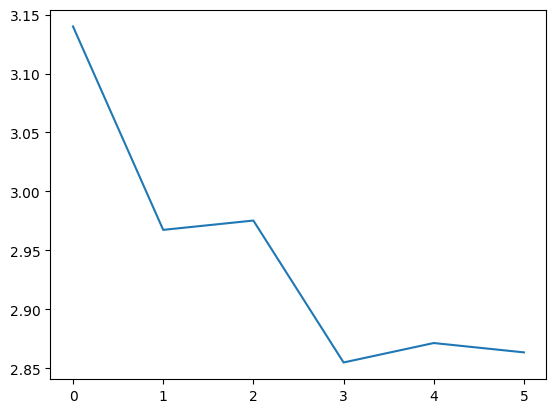

In [24]:
plt.figure()
plt.plot(stddev_grp)

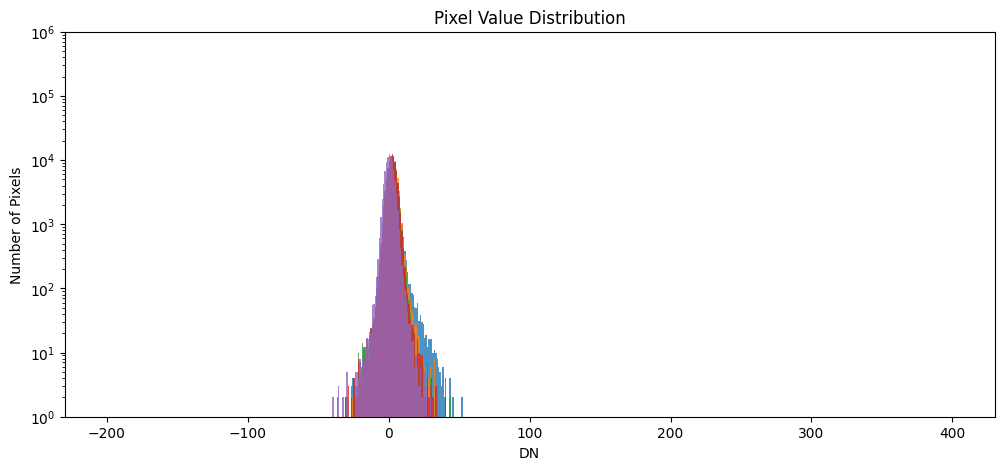

In [26]:
# test
plt.figure(figsize=(12, 5))
plt.hist(delta_masked[0], bins=range(dn_min, dn_max+1), alpha=0.8, log=True)
plt.hist(delta_masked[1], bins=range(dn_min, dn_max+1), alpha=0.8, log=True)
plt.hist(delta_masked[2], bins=range(dn_min, dn_max+1), alpha=0.8, log=True)
plt.hist(delta_masked[3], bins=range(dn_min, dn_max+1), alpha=0.8, log=True)
plt.hist(delta_masked[4], bins=range(dn_min, dn_max+1), alpha=0.8, log=True)
plt.title('Pixel Value Distribution')
plt.xlabel('DN')
plt.ylabel('Number of Pixels')
plt.ylim(1,1e6)
plt.show()